# SES 230 Term Project Final Report

**Project title:** Rock Composition: Age vs Tectonic Setting  
**Group name or number:** Jupiter  
**Group members:** Amanda Byrd, Bryan Kemp, Cambria Leben, Ramsey Joseph, Reese Woodward  
**Date:** May 6th, 2026

## Report Guidelines

- Target length: **3,000-4,000 words**, excluding references, figures, and tables.
- Figure and table captions are included in the word count.
- This notebook must run from start to finish without errors.
- Tables in this notebook must be generated with **pandas**.
- Figures in this notebook must be generated with **matplotlib**.
- Do not rely on manual steps that are not documented in this notebook.



## Reproducibility Summary

Complete this section before submission.

- **Python version:** 3.13.9
- **Main packages used:** pandas, ipykernel
- **Data location:** data/raw
- **External data access requirements:** None
- **Notebook run status:** Good

In [12]:
# Standard imports for the final report.
# Add other imports only as needed for your project.
from pathlib import Path
import re
import webbrowser

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [13]:
# Define project paths.
# Adjust these paths if your repository structure is different.
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" 
OUTPUT_DATA = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
MAP_DIR = FIG_DIR


## 1. Introduction

State the scientific motivation for your project. Introduce the broader topic, explain why it matters, and identify the specific problem your group investigated.

Include

Background and context

Throughout Earth, there are dozens of different kinds of rocks, made of dozens of different kinds of minerals. However, the Earth didn’t always start that way. Minerals used to be much more simple before different processes, some being geological, shaped the diversity of minerals. This is known as mineral evolution, how the minerals that make up Earth have changed to be more complex over time. This, however, is not the only process that has control over the diversity of minerals. Different tectonic settings, along plate boundaries or in the middle of plates, such as convergent, divergent, and hotspots \(intraplate\), also create different composition of rocks. Both time and environment shape the composition of major elements such as weight % of  SiO2, MgO2, TiO2, FeO, K2O. Basalts, mafic \(silica poor\), extrusive, igneous rock are found at almost all tectonic environments. These environments can include ocean floor and ridge, ocean island, orogenic, continental, spreading center island, and hotspot. Due to the amount of energy going into these events, all settings have volcanism, which is why basalt it so prevalent. If basalt is not there, andesite is also likely. The composition of basalts was directly affected by mineral evolution as they are comprised of ~50% SiO2, a mineral that evolved later on in Earths history. However basalts can have variation due to tectonic environments. 

Research question or hypothesis

..There seems to be some sort of balance between minerals having been diversified through time but rock composition being effected by tectonic environments. This raises the question, which one has more of an effect? Over time evolution has created increasingly more complex minerals that allow for the diversification of rock types, however is it the main controlling factor? Different tectonic environments are known to create different rock compositions, further than just basalts. This is exposed through different types of igneous and metamorphic rocks. Data collected from varying locations and ages suggests that tectonic environment has more control on the composition of rocks. Geochemical composition in igneous rock samples of basalt and andesite between 4000 and 300 Ma is more heavily influenced by geological environments such as divergent, convergent, and intraplate rather than by time.

Brief explanation of the approach

..In order to test this hypothesis, different geochemical databases with data on age, classification, and location will be collected. Data is first split by classification of rock type, such as basalt. Data will then be cleaned and standardized, deleting missing values or adding further detail. This can be formatted into a CSV to easily call upon in the code. It can then be split into tectonic setting categories such as divergent \(mid\-ocean ridge\), convergent \(arc\), and intraplate \(hotspot\). In order to create the comparison , data can further be split by age. We would prefer to work with the older rocks, such as Precambrian, to further look at how mineral evolution has effected composition, however there is an extreme lack of data from that timespan. From there, using the code to create plots, geochemical weight % over time by tectonic environment can be viewed. This approach should allow for a direct comparison of how time \(age\) and tectonic environment are effecting the composition \(wt %\) of the rock. Overall, basalts are used due to their appearance in all settings and that comparing one rock types avoids the confusion of differing composition between differing classifications. How this project is done displays a simple overview of the problem without getting caught in too many details that may make it overwhelming, perfect for an undergrad half semester project. 

Summary of expected scientific relevance

..Understanding different rock compositions from different environments will always have its importance in studies such as critical minerals. The relevance of this particular study is to further understand variations in Earth and those processes that follow. Understanding what rock types are created, where and why, is not just important for what we want to mine, but also for our future. 


## 2. Data

# Data Sources

The following sources were used to build a dataset for the project:
- GeoROC database
- PetDB database
- EarthChem database
- Additional datasets: McCoy-West (2010), Tornare (2017)
- Furthermore, the following sources were used to develop system-level age estimates for some rock populations: Mahoney et al. (1993), Tejada et al. (1996, 2002), Coffin & Eldholm (1994), Duncan (2002), Frey et al. (2000), Hofmann et al. (1997), Pik et al. (1999), Courtillot et al. (2003)

# Variables
The following variables were extracted or estimated for each data point:
- Oxide (wt%)
- Age (Ma)
- Tectonic setting ( categorized as Mid-Ocean Ridge Basalt, Arc Basalt, or Hotspot)
- Latitude & longitude (degrees)
- Source paper or dataset
- Rock type and sample ID (where available)

# Data filtering
To manage the scope of our project, which is surveying the composition of igneous rocks in broad tectonic settings around the world over long periods of time, we elected to focus on basalts. Ultimately, based on the scope of the data available to us, we elected only to include data up to approximately 200 Ma old. Furthermore, we filtered our large datasets for basaltic rocks that could be cateforized into one of our broad tectonic settings:
- Divergent plate boundary (Mid-Ocean Ridge Basalts, or MORB)
- Convergent plate bounday (Arc)
- Intraplate tectonics (Hotspot)

We then selected only data points for which major element oxide weight percentages existed.

# Limitations
For many data points, tectonic setting and oxide wt% was available in the original dataset. However, age measurements and, in the McCoy-West and Tornare datasets, longitude and latitude were missing. For samples missing age measurements, the source rock population was used to estimate the age of the samples based on supplementary literature (refer to the data sources listed above). When location coordinates were missing, the original paper was reviewed for the source rock location, and an approximate longitude and latitude were determined.

# Data Source Citations
+ Martin, Erin L. et al. GEOSCRAPE zircon database (2021)
+ Pilger, Rex H. Jr. Radiometric Dates from the South American Andes and Adjacent Areas: A Compilation - part 1 igneous rocks (2022)
+ Qin et al. Global mantle clinopyroxene data (major and trace elements) 2021.
+ Stracke et al.	Major and trace element concentrations and Sr, Nd, Hf, Pb isotope ratios of global mid ocean ridge and ocean island basalts (2022).
+ Tappe, Sebastian. Global magmatic kimberlite and carbonatite compositions (elemental and isotopic)	(2017).
+ Wörner, Gerhard et al.	Geochemical compositions of igneous rocks of the Central Andean orocline	(2009).
+ McCoy-West, A. J. et al. Petrogenesis and Origins of Mid-Cretaceous Continental Intraplate Volcanism in Marlborough, New Zealand: + Implications for the Long-lived HIMU Magmatic Mega-province of the SW Pacific (2010).
+ Tornare, E., Pilet, S., & Bussy, F. Magma Differentiation in Vertical Conduits Revealed by the Complementary Study of Plutonic and Volcanic Rocks from Fuerteventura (Canary Islands) (2017).


In [14]:
PROJECT_ROOT = Path.cwd()

DATA_FILE = PROJECT_ROOT / "data" / "cleaned_dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_FILE)
print("Figures directory:", FIGURES_DIR)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find cleaned dataset at: {DATA_FILE}")

df_all = pd.read_csv(DATA_FILE)

numeric_columns = [
    "SiO2",
    "MgO",
    "TiO2",
    "K2O",
    "Age_Ma",
    "Latitude",
    "Longitude",
]

for col in numeric_columns:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

bin_size = 50
df_all["Age_Bin"] = ((df_all["Age_Ma"] // bin_size) * bin_size) + (bin_size / 2)

print("Dataset shape:", df_all.shape)

print("\nColumns:")
print(df_all.columns.tolist())

print("\nSamples by setting:")
print(df_all["Setting"].value_counts(dropna=False))

print("\nCoordinate counts by setting:")
print(df_all.groupby("Setting")[["Latitude", "Longitude"]].count())

display(df_all.head())

Project root: c:\Users\ramse\Documents\AnacondaProjects\TermProject
Data file: c:\Users\ramse\Documents\AnacondaProjects\TermProject\data\cleaned_dataset.csv
Figures directory: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures
Dataset shape: (530, 12)

Columns:
['SiO2', 'MgO', 'TiO2', 'K2O', 'Age_Ma', 'Latitude', 'Longitude', 'Setting', 'Source', 'Rock_type', 'Sample', 'Age_Bin']

Samples by setting:
Setting
HOTSPOT    303
ARC        175
MOR         52
Name: count, dtype: int64

Coordinate counts by setting:
         Latitude  Longitude
Setting                     
ARC           175        175
HOTSPOT       303        303
MOR            52         52


,SiO2,MgO,TiO2,K2O,Age_Ma,Latitude,Longitude,Setting,Source,Rock_type,Sample,Age_Bin
0,51.05,6.73,2.20,0.15,13.64,10.58,-42.707,MOR,Stracke 2022,NaN,NaN,25.0
1,50.47,7.87,1.42,0.07,24.55,10.68,-44.420,MOR,Stracke 2022,NaN,NaN,25.0
2,51.38,7.49,1.73,0.13,3.68,10.70,-41.352,MOR,Stracke 2022,NaN,NaN,25.0
3,50.47,7.44,1.77,0.13,0.80,10.70,-41.000,MOR,Stracke 2022,NaN,NaN,25.0
4,50.84,8.21,1.47,0.10,3.11,10.72,-41.287,MOR,Stracke 2022,NaN,NaN,25.0


## 3. Code and Methods

#### Computational Workflow
The computational workflow used throughout this project was designed to standardize several geochemical datasets into one single structure that is usable for a comparative analysis. The raw datasets we obtained from EarthChem, GeoRoc, and PetDB were imported as CSV files which were then processed using extraction functions we made in Python, assisted by ChatGPT and Codex.  Using the extraction functions, we cleaned, filtered, and standardized the datasets before merging them into one individual Pandas DataFrame. The processed data was then grouped by their tectonic setting and age in order to generate comparative geochemical visuals using matplotlib.

![Workflow](figures/Code_Diagram.drawio.png)


#### Data Extraction and Cleaning
The main challenges we faced in this project were the inconsistencies in the geochemical databases. When downloading the different datasets we saw that they included different column names, formatting, tectonic setting labels, and methods for storing information. To work around this issue we made custom extraction functions in Python that would standardize the data we were importing. It was important to extract the oxide measurements of SIO_2, MgO, TiO_2, and K_2O while also making sure to preserve the samples age, latitude, longitude, and tectonic setting. We used Pandas to do our data cleaning to create a single dataset that included all of the information formatted the same. Any values that were missing or invalid were removed from the dataset. The tectonic settings from our datasets when standardized were compiled into three different categories: HOTSPOT (intraplate), ARC (convergent), and MOR, (mid-ocean-ridges). The analysis was mainly focused on basaltic and andesitic rocks because they are commonly found in multiple tectonic settings and allow for more direct data comparisons. The extraction functions were organized into Python scripts in the projects repository, and these functions allowed for the different datasets to be processed independently while still providing a consistent final structure. By organizing the workflow into modular functions our code’s readability, reproducibility, and debugging efficiency were improved.
#### Dataset Extraction
After we extracted and processed the data, the cleaned datasets were merged into a single Pandas DataFrame. Each dataset contained standardized columns that represented geochemical composition, tectonic setting, age, and location. Combining the datasets into a single structure simplified filtering, grouping, and plotting operations. The reason the data was filtered was to remove any invalid samples and keep only the ones that were relevant to the project’s hypothesis. 
Example dataset integration step:
df_all = pd.concat(
    [morb, oib, arc, tornare, petdb],
    ignore_index=True
)
#### Age Estimation and Binning
Not all of the datasets we imported included precise ages for each rock sample, and in some cases only the minimum and maximum age ranges were available. To estimate the age for these samples the midpoint formula was used:
The midpoint age was estimated using:

$$
\mathrm{midpoint} = \frac{\mathrm{min\_age} + \mathrm{max\_age}}{2}
$$
The approximation relies on the assumption that the midpoint represents the average age of each sample. Although it is not 100% accurate and is very simplified using this method allows us to use datasets with incomplete age information. For us to compare long-term geochemical trends the samples were grouped into age bins. We included 50 Ma, 25 Ma, and 10 Ma bins. The age bins were calculated by using floor division operations in Python. For example the 50 Ma bins were made by:
The data were grouped into 50 Ma age bins using:

$$
\mathrm{AgeBin} =
\left(
\left\lfloor
\frac{\mathrm{Age}_{Ma}}{50}
\right\rfloor
\times 50
\right)
+ 25
$$
Binning helped by reducing variability and noise while also improving the visible comparison between the tectonic settings over time. Testing multiple bin sizes allowed the project to cover how sampling density and temporal resolution affected the observed geochemical trends.
#### Visualization and Analytical Methods
Matplotlibs were used to visualize the geochemical trends, and multi-panel figures were made for the oxide concentrations across different tectonic settings and age bins. Each tectonic category was plotted separately in order to compare geochemical variation through time. Line plots were used to show the averages within each age bin and the shaded regions show the uncertainty within the dataset. These visualizations allow for direct comparison between temporal variation and tectonic setting. By plotting several environments at the same time, it became possible to see whether rock composition changed more over time than by tectonic setting. Multiple binning intervals were tested to figure out whether or not the observed trends remained consistent at different temporal resolutions. The figures mentioned were generated in Jupyter Notebook using matplotlib so that we could maintain reproducibility.


## 4. Results

We have found that while there is some variation in wt% over time, the tectonic setting has more of an affect on the geochemical composition. The composition visually appears more predictable based on tectonic setting than time over the last ~200 Ma. For convergent or arc settings, $SiO_2$ had around 54 wt%, more than MgO, $SiO_2$, and $K_2O$ combined, of which were about even. Intraplate or hotspots had around 49 wt% of $SiO_2$, with higher levels of MgO and occasionally $TiO_2$ than most arc settings. Finally, divergent or mid-ocean ridges held around 47 wt% of $SiO_2$ with the highest levels of $SiO_2$ and lowest levels of MgO and $K_2O$ of the three settings.

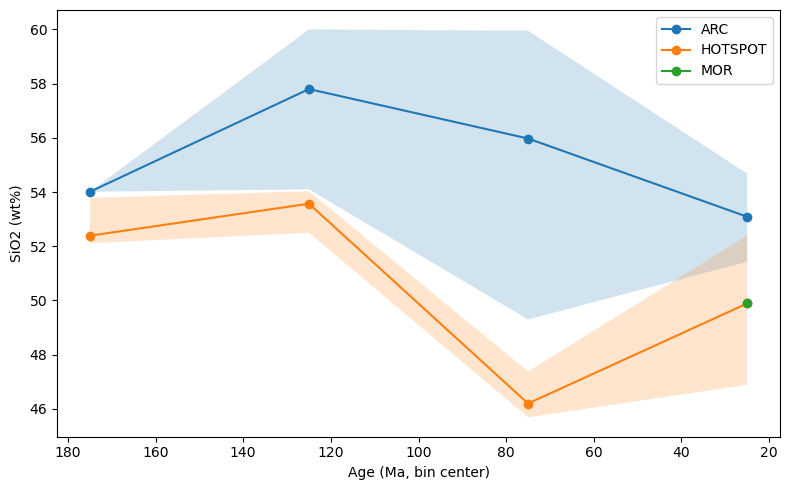

Saved: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\sio2_vs_age.png


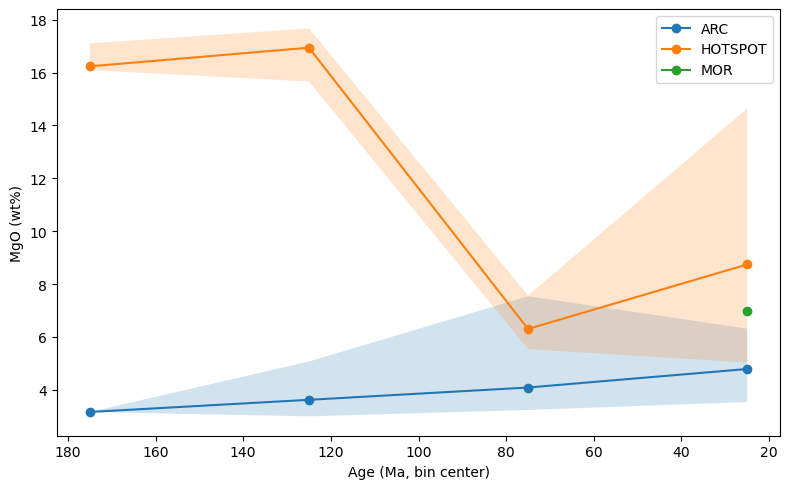

Saved: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\mgo_vs_age.png


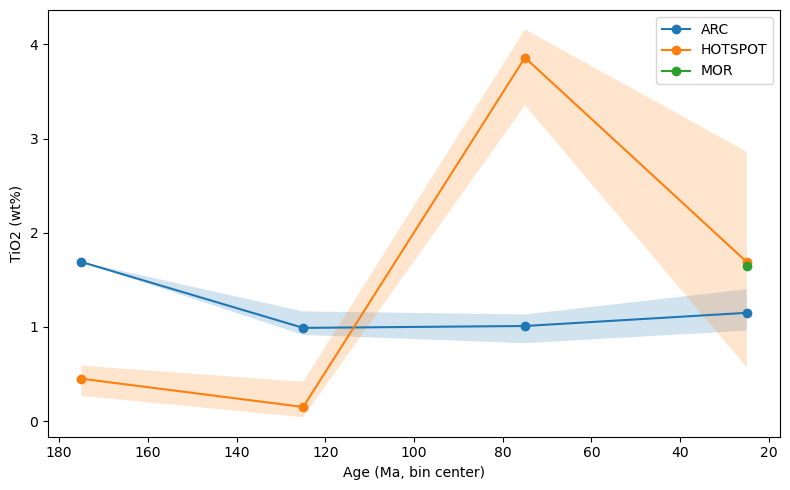

Saved: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\tio2_vs_age.png


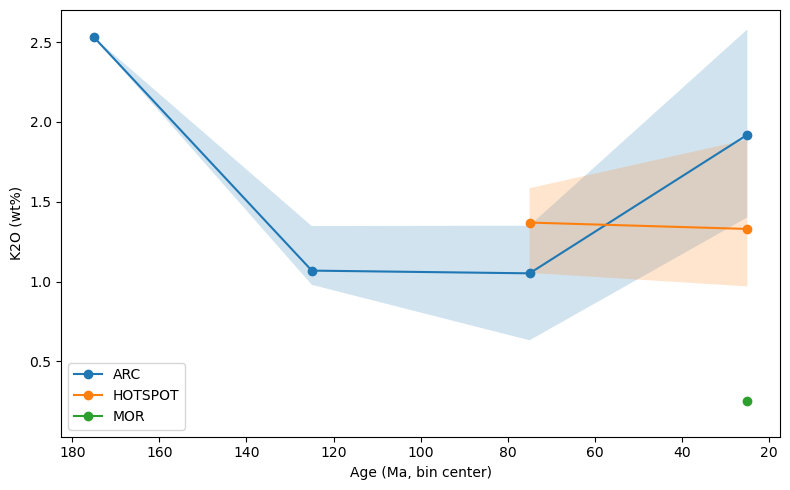

Saved: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\k2o_vs_age.png


In [15]:
def plot_element_vs_age(
    df: pd.DataFrame,
    element: str,
    outpath: Path,
    ylabel: str | None = None,
):
    """
    Plot median and interquartile range of one oxide through time.
    Uses 50 Ma centered age bins.
    """
    if element not in df.columns:
        print(f"Skipping {element}: column not found.")
        return

    if ylabel is None:
        ylabel = element

    plot_df = df.dropna(subset=[element, "Age_Bin", "Setting"]).copy()

    if plot_df.empty:
        print(f"Skipping {element}: no usable data.")
        return

    stats = (
        plot_df
        .groupby(["Setting", "Age_Bin"])[element]
        .agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            n="count",
        )
        .reset_index()
        .sort_values(["Setting", "Age_Bin"])
    )

    plt.figure(figsize=(8, 5))

    for setting in stats["Setting"].unique():
        sub = stats[stats["Setting"] == setting].sort_values("Age_Bin")

        x = sub["Age_Bin"].to_numpy(dtype=float)
        median = sub["median"].to_numpy(dtype=float)
        q25 = sub["q25"].to_numpy(dtype=float)
        q75 = sub["q75"].to_numpy(dtype=float)

        plt.plot(x, median, marker="o", label=setting)
        plt.fill_between(x, q25, q75, alpha=0.2)

    plt.gca().invert_xaxis()
    plt.xlabel("Age (Ma, bin center)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print(f"Saved: {outpath}")


# Generate oxide plots
plot_element_vs_age(df_all, "SiO2", FIGURES_DIR / "sio2_vs_age.png", ylabel="SiO2 (wt%)")
plot_element_vs_age(df_all, "MgO", FIGURES_DIR / "mgo_vs_age.png", ylabel="MgO (wt%)")
plot_element_vs_age(df_all, "TiO2", FIGURES_DIR / "tio2_vs_age.png", ylabel="TiO2 (wt%)")
plot_element_vs_age(df_all, "K2O", FIGURES_DIR / "k2o_vs_age.png", ylabel="K2O (wt%)")

**Figure 1.** Element v. Age plots. Blue for arc, orange for hotspot, green for mid-ocean ridge. Shows the relationship of specific elements of different settings against time .

In [16]:
# Prepare data for maps
map_df = df_all.dropna(subset=["Latitude", "Longitude", "Age_Bin", "Setting"]).copy()

# Use presentation-friendly label for MOR
map_df["Map_Setting"] = map_df["Setting"].replace({"MOR": "MORB"})

# Make age bins categorical so Plotly uses discrete colours
bin_order = sorted(map_df["Age_Bin"].dropna().unique().tolist())
bin_labels = [f"{b:g} Ma" for b in bin_order]

map_df["Age_Bin_Label"] = map_df["Age_Bin"].map(lambda x: f"{x:g} Ma")
map_df["Age_Bin_Label"] = pd.Categorical(
    map_df["Age_Bin_Label"],
    categories=bin_labels,
    ordered=True,
)

for setting in ["MORB", "ARC", "HOTSPOT"]:
    sub = map_df[map_df["Map_Setting"] == setting].copy()

    if sub.empty:
        print(f"No coordinate data available for {setting}")
        continue

    hover_cols = [
        col for col in ["Age_Ma", "Age_Bin", "SiO2", "MgO", "TiO2", "K2O", "Source"]
        if col in sub.columns
    ]

    fig = px.scatter_geo(
        sub,
        lat="Latitude",
        lon="Longitude",
        color="Age_Bin_Label",
        category_orders={"Age_Bin_Label": bin_labels},
        color_discrete_sequence=px.colors.qualitative.Bold,
        projection="natural earth",
        title=f"{setting} samples coloured by 50 Ma age bin",
        hover_data=hover_cols,
    )

    fig.update_traces(
        marker=dict(
            size=8,
            opacity=1.0,
            line=dict(width=0.8, color="black"),
        )
    )

    fig.update_geos(
        showland=True,
        landcolor="rgb(240,240,240)",
        showcountries=True,
        showocean=True,
        oceancolor="rgb(220,235,245)",
    )

    out_html = FIGURES_DIR / f"{setting.lower()}_map.html"
    fig.write_html(out_html)

    print(f"Saved map: {out_html}")
    fig.show()

Saved map: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\morb_map.html


Saved map: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\arc_map.html


Saved map: c:\Users\ramse\Documents\AnacondaProjects\TermProject\figures\hotspot_map.html


**Figure 2.** Map plots. Shows plots on a map where specific samples of specific settings were taken, color coded by age.

## 5. Discussion

Our results show how a comparison between age and tectonic setting for rocks types can be underdone. The figures created by our code reveal that although there is a difference in mineral wt % between the different tectonic settings, there is also some major differences in composition over time. From the little amount of data we were able to cover, out results reveal that there is major differences in composition not only from tectonic setting but also from age. When analyzing under the 50 Ma bins, the plots of SiO2, TiO2, MgO, and K2O all have major changes in those composition along the x axis (age). Due to this fact, I would say the code does not support our hypothesis as it was orginally thought that tectonic setting would have a much noticeably larger effect. In the 1977 work done by Pearce et al. [2] the authors study the geochemical composition of different basalts in the Cenozoic in order to derive their tectonic environment. This study is similar to ours, they just did not do a comparison of age. They find that orogenic has a lower MgO content than ocean island, which is what our graphs plot as well. Furthermore the authors find that orogenic has a higher SiO2 content than ocean island, like the graphs we created. Unfortunately, for the wt % of TiO2, our data was the opposite of that study. Although on our graph the TiO2 value is higher in younger hotspot locations than younger arc locations. For clarification, our study uses orogenic as 'arc' and ocean island as 'hotspot' since they are related. This project was very limited both by the data we were able to access and the time we had to process it. More specifically, incomplete geological records, uneven sampling, and approximate ages were some of our biggest limits with data. With more time and a wider set of data, this project could receive much greater detail and proper analysis. Overall, geochemistry changes with tectonic setting because the formation of new materials require specific, localized chemical and physical conditions (High temp, high pressure, water, oxygen, etc.) as well as the passage of time, as seen in Pearce et. al 1977. 

## 6. References

List all references cited in the report. Use a consistent citation style.

\[1\] Hazen, R. M. et al. Mineral evolution. Am. Mineral. 93, 1693–1720 \(2008\). 

\[2\] Pearce, T. H., Gorman, B. E. & Birkett, T. C. The relationship between major element chemistry and tectonic environment of basic and intermediate volcanic rocks. Earth Planet. Sci. Lett. 36, 121–132 \(1977\).

\[3\] Condie, K. Trace\-element geochemistry of archean greenstone belts. Earth\-Sci. Rev. 12, 393–417 \(1976\). 

\[4\] Ponomar, V. & Gavryliv, L. Unveiling carbonate mineral evolution across geological timescales using an integrated mineral database approach. Earth\-Sci. Rev. 272, 105206 \(2026\). 

https://georoc.eu/georoc/expert/  

https://search.earthchem.org/ 

Also include the exported Zotero library in the `zotero/` directory of your GitHub repository as a `.bib` or `.ris` file.



## 7. Statement of AI Use

Complete this required statement.

- **Where AI was used:** ChatGPT was used for planning and hypothesis refinement, and ChatGPT and Codex were used extensively in data management and coding and methods.
- **Tasks AI was used for:** Literature summaries, code design and planning, extraction functions, concatenation functions, data/results visualization, troubleshooting and validation.
- **Confirmation about report text:** We confirm that AI was not used to generate the final report text.


## 8. Role Statement

Describe each group member's contributions. Include both assigned roles and any help provided beyond assigned roles.

| Group member | Primary responsibilities | Additional contributions |
| :---------------- | :------------------------------------------------------------- | :------------------------------------ |
| Cambria Leben | Literature Review, Interpretation/Discussion, Zotero Library | Worked on a couple extra slides |
| Reese Woodward | Data | Assisted with project scope/geology expertise |
| Amanda Byrd | Code, Interpretation/Discussion | Assisted with map images |
| Bryan Kemp | Code | Assisted with map images |
| Ramsey Joseph | PI: Results, Interpretation/Discussion, Statement of AI use | Assisted with Data, Code and Methods |
| :-------------------------- |

Replace with additional contributions |



## 9. Final Reproducibility Checklist

Complete this checklist before submission.

- [x ] This notebook runs from start to finish without errors.
- [x ] All data-loading steps are included or clearly documented.
- [x ] All data files are included in the repository or accessible through a documented external link.
- [x ] Tables are generated with pandas.
- [x ] Figures are generated with matplotlib.
- [x ] Figure and table captions are included.
- [x] The Statement of AI Use is complete.
- [x ] The Role Statement is complete.
- [x ] References are complete and consistent.
- [x ] The Zotero export is included in the repository.